# Bike Sharing Demand Prediction
## Step 3: Model Building & Evaluation
**Name:** Nitin | **Roll No:** 2323008

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [19]:
# Load cleaned dataset
bike_data = pd.read_csv("Datasets/final_dataset.csv")
print('Dataset loaded:', bike_data.shape)
bike_data.head()

Dataset loaded: (731, 11)


,season,year,month,holiday,weekday,workingday,weather,temp,humidity,windspeed,total_rentals
0,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,985
1,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,801
2,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,1349
3,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,1562
4,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,1600


In [8]:
# Define features and target
input_features = ['season', 'year', 'month', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed']
target_col = 'total_rentals'

X = bike_data[input_features]
y = bike_data[target_col]
print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (731, 9)
Target shape: (731,)


In [9]:
# One-hot encode categorical features
categorical_features = ['season', 'year', 'month', 'holiday', 'workingday', 'weather']
X_processed = pd.get_dummies(X, columns=categorical_features, drop_first=True)
print('After encoding, feature count:', X_processed.shape[1])

After encoding, feature count: 22


In [10]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=10
)
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 584
Testing samples: 147


### Model 1: Linear Regression
A simple baseline model that assumes a linear relationship between features and rentals.

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_predictions = lr.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_predictions)
lr_rmse = mean_squared_error(y_test, lr_predictions) ** 0.5
lr_r2   = r2_score(y_test, lr_predictions)

print('=== Linear Regression ===')
print(f'MAE  : {lr_mae:.2f}')
print(f'RMSE : {lr_rmse:.2f}')
print(f'R²   : {lr_r2:.4f}')

=== Linear Regression ===
MAE  : 625.75
RMSE : 832.71
R²   : 0.8176


In [12]:
# Top influencing features from Linear Regression
coeff_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr.coef_})
coeff_df = coeff_df.reindex(coeff_df['Coefficient'].abs().sort_values(ascending=False).index)
print('Top 10 influential features:')
print(coeff_df.head(10).to_string(index=False))

Top 10 influential features:
  Feature  Coefficient
     temp  4584.219826
windspeed -2946.074968
   year_1  2022.933815
weather_3 -1835.216398
 season_4  1509.025591
 humidity -1469.000319
  month_9   946.658590
  month_5   893.426952
 season_3   763.699849
 season_2   738.439398


### Model 2: Decision Tree Regressor
A non-linear model that splits data into branches based on feature thresholds.

In [13]:
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=10)
dt.fit(X_train, y_train)
dt_predictions = dt.predict(X_test)

dt_mae  = mean_absolute_error(y_test, dt_predictions)
dt_rmse = mean_squared_error(y_test, dt_predictions) ** 0.5
dt_r2   = r2_score(y_test, dt_predictions)

print('=== Decision Tree ===')
print(f'MAE  : {dt_mae:.2f}')
print(f'RMSE : {dt_rmse:.2f}')
print(f'R²   : {dt_r2:.4f}')

=== Decision Tree ===
MAE  : 649.40
RMSE : 925.04
R²   : 0.7749


### Model 3: Random Forest Regressor
An ensemble of decision trees that reduces overfitting and improves accuracy.

In [14]:
rf = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=10)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_predictions)
rf_rmse = mean_squared_error(y_test, rf_predictions) ** 0.5
rf_r2   = r2_score(y_test, rf_predictions)

print('=== Random Forest ===')
print(f'MAE  : {rf_mae:.2f}')
print(f'RMSE : {rf_rmse:.2f}')
print(f'R²   : {rf_r2:.4f}')

=== Random Forest ===
MAE  : 506.86
RMSE : 721.42
R²   : 0.8631


### Model Comparison

In [15]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE':   [round(lr_mae,2), round(dt_mae,2), round(rf_mae,2)],
    'RMSE':  [round(lr_rmse,2), round(dt_rmse,2), round(rf_rmse,2)],
    'R2':    [round(lr_r2,4), round(dt_r2,4), round(rf_r2,4)]
})
print(comparison.to_string(index=False))

            Model    MAE   RMSE     R2
Linear Regression 625.75 832.71 0.8176
    Decision Tree 649.40 925.04 0.7749
    Random Forest 506.86 721.42 0.8631


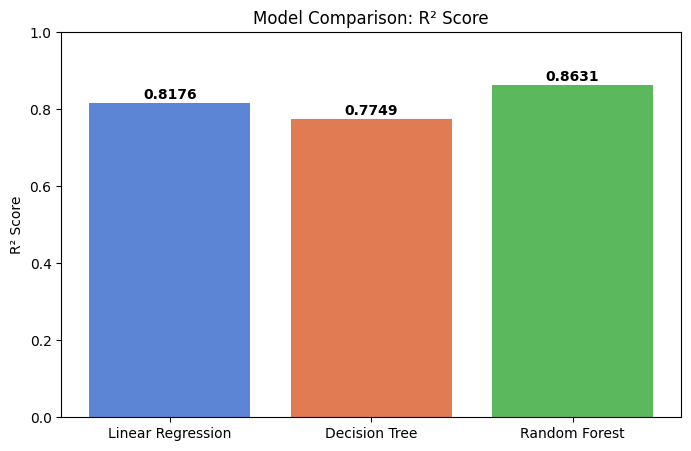

In [16]:
# Bar chart: R² comparison
plt.figure(figsize=(8, 5))
colors = ['#5C85D6', '#E07B54', '#5CB85C']
plt.bar(comparison['Model'], comparison['R2'], color=colors)
plt.ylim(0, 1)
plt.ylabel('R² Score')
plt.title('Model Comparison: R² Score')
for i, v in enumerate(comparison['R2']):
    plt.text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.show()
# Conclusion: Random Forest achieves the best R² score

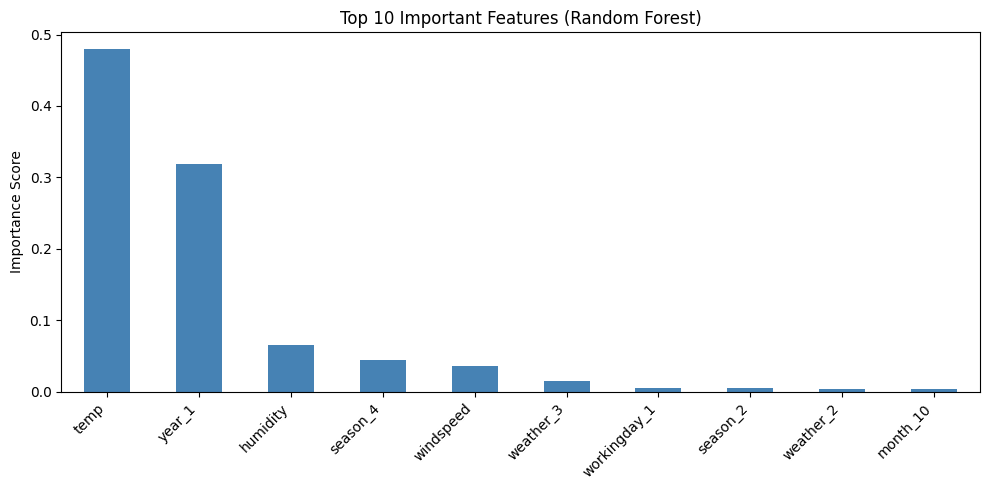

In [17]:
# Feature importance from Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Top 10 Important Features (Random Forest)')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Conclusion
- **Linear Regression** gives a decent baseline but misses non-linear patterns.
- **Decision Tree** can overfit without depth control; tuning helps.
- **Random Forest** performs best overall — it handles non-linearity and noise through ensemble averaging.
- Key factors influencing rentals: **temperature, year, season, and month**.